In [ ]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

from scipy import stats
from scipy.stats import spearmanr

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
import nltk


from sklearn.decomposition import PCA

from nltk.corpus import wordnet as wn

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import scikit_posthocs as sp
from sklearn.metrics import adjusted_rand_score

from sklearn.cluster import KMeans

from scipy.spatial.distance import squareform

from scipy.cluster.hierarchy import linkage, fcluster

from scipy.cluster.hierarchy import dendrogram


import pickle

import matplotlib.pyplot as plt

import seaborn as sns

from skbio.stats.distance import mantel

from umap import UMAP

from sklearn.manifold import TSNE

import networkx as nx

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6254.90it/s]


In [15]:
# carico il dataset
taxonomic_tree = pd.read_csv("taxonomic_pairs.csv")

#codice da eseguire per avere gli embedding

import pickle

with open("embeddings.pkl_2", "rb") as f:
    embeddings = pickle.load(f)

In [4]:
#Estrazione delle PCA (50,10,2 D)
#converto dizionario di embedding in una matrice Numpy
#creo una lista contenente le chiavi del dizionario
words = list(embeddings.keys())
#creo la matrice degli embedding vstack impila vettori e adatto tensor pytorch a numpy
embedding_matrix_2 = np.vstack([
    embeddings[word].numpy()
    for word in words
])

print(embedding_matrix_2.shape)

(20, 384)


In [ ]:
#PCA 50 D: Impossibile creare PCA di dimensioni maggiori rispetto al numero deile parole da estrare
pca_50 = PCA(n_components=50)
pca_50_embedding = pca_50.fit_transform(embedding_matrix_2)
print("Dimensione della matrice dopo PCA 50 D:", pca_50_embedding.shape)
print("Varianza spiegata totale:", pca_50.explained_variance_ratio_.sum())

ValueError: n_components=50 must be between 0 and min(n_samples, n_features)=20 with svd_solver='full'

In [8]:
#PCA 10 D
pca_10 = PCA(n_components=10)
pca_10_embedding = pca_10.fit_transform(embedding_matrix_2)
print("Dimensione della matrice dopo PCA 10 D:", pca_10_embedding.shape)
print("Varianza spiegata totale:", pca_10.explained_variance_ratio_.sum())

Dimensione della matrice dopo PCA 10 D: (20, 10)
Varianza spiegata totale: 0.747138


In [9]:
#PCA 2 D
pca_2 = PCA(n_components=2)
pca_2_embedding = pca_2.fit_transform(embedding_matrix_2)
print("Dimensione della matrice dopo PCA 2 D:", pca_2_embedding.shape)
print("Varianza spiegata totale:", pca_2.explained_variance_ratio_.sum())

Dimensione della matrice dopo PCA 2 D: (20, 2)
Varianza spiegata totale: 0.26048493


In [10]:
#riassunto
print("Varianza spiegata totale di PCA 10 D:", pca_10.explained_variance_ratio_.sum())
print("Varianza spiegata totale di PCA 2 D:", pca_2.explained_variance_ratio_.sum())

Varianza spiegata totale di PCA 10 D: 0.747138
Varianza spiegata totale di PCA 2 D: 0.26048493


In [11]:
#ricreo dizionari di embeddings

diz_embeddings_pca_10 = {
    word: pca_10_embedding [i]
    for i, word in enumerate(words)
}

diz_embeddings_pca_2 = {
    word: pca_2_embedding [i]
    for i, word in enumerate(words)
}

In [12]:
#rifaccio secondo esperimento per le tre distribuzioni:


#funzione per la cosine similarity

def add_cosine_similarity(df, col1, col2, diz_embedding ):
    #in input entrano: il database delle coppie, la colonna della parola e la colonna della parola associata, il dizionario della PCA
    #si crea una lista  per i risultati della cosine similarity
    #si calcola la cosine similarity usando gli embedding già calcolati
    #si crea una colonna nel dataset di partenza con i risultati della cosine similarity
    
    similarities = []

    for w1, w2 in zip(df[col1], df[col2]):

        emb1 = diz_embedding[w1]
        emb2 = diz_embedding[w2]

        similarity = cos_sim(
            emb1,
            emb2
        ).item()

        similarities.append(similarity)


    df["cosine_similarity"] = similarities

    return df

In [16]:
#funzione applicata all'albero per ogni PCA

taxonomic_10_df = add_cosine_similarity(
    taxonomic_tree.copy(),
    "word1",
    "word2",
    diz_embeddings_pca_10
)


taxonomic_2_df = add_cosine_similarity(
    taxonomic_tree.copy(),
    "word1",
    "word2",
    diz_embeddings_pca_2
)


print(f"PCA 10:\n{taxonomic_10_df.head()}")
print(f"\nPCA 2:\n{taxonomic_2_df.head()}")

PCA 10:
     word1       word2  taxonomic_distance  cosine_similarity
0  vehicle      rocket                   1          -0.047595
1  vehicle     missile                   2           0.063023
2  vehicle  sidewinder                   3          -0.137168
3  vehicle       craft                   1          -0.215640
4  vehicle    aircraft                   2           0.533277

PCA 2:
     word1       word2  taxonomic_distance  cosine_similarity
0  vehicle      rocket                   1           0.942421
1  vehicle     missile                   2           0.915753
2  vehicle  sidewinder                   3          -0.563343
3  vehicle       craft                   1          -0.909389
4  vehicle    aircraft                   2           0.999830


In [18]:
#Calcolo la Cosine distance (1- cosine similarity)
#PCA 10
taxonomic_10_df["cosine_distance"] = 1 - taxonomic_10_df["cosine_similarity"]

#PCA 2
taxonomic_2_df["cosine_distance"] = 1 - taxonomic_2_df["cosine_similarity"]


print(f"PCA 10:\n{taxonomic_10_df.head()}")

print(f"\nPCA 2:\n{taxonomic_2_df.head()}")

PCA 10:
     word1       word2  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1          -0.047595         1.047595
1  vehicle     missile                   2           0.063023         0.936977
2  vehicle  sidewinder                   3          -0.137168         1.137168
3  vehicle       craft                   1          -0.215640         1.215640
4  vehicle    aircraft                   2           0.533277         0.466723

PCA 2:
     word1       word2  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.942421         0.057579
1  vehicle     missile                   2           0.915753         0.084247
2  vehicle  sidewinder                   3          -0.563343         1.563343
3  vehicle       craft                   1          -0.909389         1.909389
4  vehicle    aircraft                   2           0.999830         0.000170


In [19]:
#salvo i risultati con la cos distance
taxonomic_10_df.to_csv(
    "results_taxonomic_tree_similarity_and_distances_PCA10.csv",
    index=False
)

taxonomic_2_df.to_csv(
    "results_taxonomic_tree_similarity_and_distances_PCA2.csv",
    index=False
)

In [20]:
#per caricare dataset con cosine similarity

taxonomic_df = pd.read_csv("results_taxonomic_tree_similarity_and_distances.csv")
taxonomic_10_df = pd.read_csv("results_taxonomic_tree_similarity_and_distances_PCA10.csv")
taxonomic_2_df = pd.read_csv("results_taxonomic_tree_similarity_and_distances_PCA2.csv")


In [25]:
#carico grafo G
with open("taxonomy_graph.pkl", "rb") as f:
    G = pickle.load(f)
    

In [26]:
#costruisco matrice partendo dal grafo dell'albero tassonomico così che gli elementi siano in ordine gerarchicamente parlando
#la distanza floys_marshall corrisponde esattamente alla short_path_distance calcloata nel dataframe, è la distanza tassonomica

sorted_keys = list(nx.topological_sort(G))

G_undirected = G.to_undirected()

dist_matrix = nx.floyd_warshall_numpy(
    G_undirected,
    nodelist=sorted_keys
)

print(dist_matrix.shape)
print(dist_matrix)

(20, 20)
[[0. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 3. 3. 3. 3. 3. 3. 3.]
 [1. 0. 2. 2. 2. 3. 3. 3. 3. 3. 3. 3. 3. 4. 4. 4. 4. 4. 4. 4.]
 [1. 2. 0. 2. 2. 1. 1. 1. 3. 3. 3. 3. 3. 4. 4. 4. 4. 4. 4. 4.]
 [1. 2. 2. 0. 2. 3. 3. 3. 1. 1. 1. 1. 3. 2. 2. 2. 2. 2. 2. 4.]
 [1. 2. 2. 2. 0. 3. 3. 3. 3. 3. 3. 3. 1. 4. 4. 4. 4. 4. 4. 2.]
 [2. 3. 1. 3. 3. 0. 2. 2. 4. 4. 4. 4. 4. 5. 5. 5. 5. 5. 5. 5.]
 [2. 3. 1. 3. 3. 2. 0. 2. 4. 4. 4. 4. 4. 5. 5. 5. 5. 5. 5. 5.]
 [2. 3. 1. 3. 3. 2. 2. 0. 4. 4. 4. 4. 4. 5. 5. 5. 5. 5. 5. 5.]
 [2. 3. 3. 1. 3. 4. 4. 4. 0. 2. 2. 2. 4. 1. 1. 1. 1. 3. 3. 5.]
 [2. 3. 3. 1. 3. 4. 4. 4. 2. 0. 2. 2. 4. 3. 3. 3. 3. 1. 1. 5.]
 [2. 3. 3. 1. 3. 4. 4. 4. 2. 2. 0. 2. 4. 3. 3. 3. 3. 3. 3. 5.]
 [2. 3. 3. 1. 3. 4. 4. 4. 2. 2. 2. 0. 4. 3. 3. 3. 3. 3. 3. 5.]
 [2. 3. 3. 3. 1. 4. 4. 4. 4. 4. 4. 4. 0. 5. 5. 5. 5. 5. 5. 1.]
 [3. 4. 4. 2. 4. 5. 5. 5. 1. 3. 3. 3. 5. 0. 2. 2. 2. 4. 4. 6.]
 [3. 4. 4. 2. 4. 5. 5. 5. 1. 3. 3. 3. 5. 2. 0. 2. 2. 4. 4. 6.]
 [3. 4. 4. 2. 4. 5. 5. 5. 1. 3. 3. 3. 5. 2. 2.

In [23]:
#HEATMAP Distanza Tassonomica PCA 10
# creo una matrice 20x20 per la taxonomic distance
#step1: creo dataset duplicato con coppie inverse
df_inverso_10 = taxonomic_10_df.rename(
    columns={
        "word1": "word2",
        "word2": "word1"
    }
)
print(f"inverso:\n{df_inverso_10.head()}")

#step 2: unisco i dataset
df_completo_10 = pd.concat([taxonomic_10_df,df_inverso_10])

print(f"completo:\n{df_completo_10.head()}")
print(len(df_completo_10))


inverso:
     word2       word1  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1          -0.047595         1.047595
1  vehicle     missile                   2           0.063023         0.936977
2  vehicle  sidewinder                   3          -0.137168         1.137168
3  vehicle       craft                   1          -0.215640         1.215640
4  vehicle    aircraft                   2           0.533277         0.466723
completo:
     word1       word2  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1          -0.047595         1.047595
1  vehicle     missile                   2           0.063023         0.936977
2  vehicle  sidewinder                   3          -0.137168         1.137168
3  vehicle       craft                   1          -0.215640         1.215640
4  vehicle    aircraft                   2           0.533277         0.466723
380


In [27]:
#creao lista ordinata di lemmi
ordered_words = [
    wn.synset(node).lemmas()[0].name()
    for node in sorted_keys
]

print(ordered_words)

['vehicle', 'steamroller', 'sled', 'craft', 'rocket', 'bobsled', 'toboggan', 'luge', 'vessel', 'spacecraft', 'aircraft', 'hovercraft', 'missile', 'galley', 'boat', 'yacht', 'ship', 'starship', 'lander', 'sidewinder']


In [29]:
#creo matrice di cosine distance a partire dal dataframe
cosine_matrix_10 = df_completo_10.pivot(
    index="word1",
    columns="word2",
    values="cosine_distance"
)



In [31]:
#cambio l'ordine degli elementi della matrice
cosine_matrix_10 = cosine_matrix_10.reindex(
    index=ordered_words,
    columns=ordered_words
)

In [32]:
#associamo i valori Nan a 0 nella diagonale principale
cosine_matrix_10 = cosine_matrix_10.copy()

for word in cosine_matrix_10.index:
    cosine_matrix_10.loc[word, word] = 0

print(dist_matrix.shape)
print(cosine_matrix_10.shape)

print(cosine_matrix_10)
print(cosine_matrix_10.isna().sum().sum())

(20, 20)
(20, 20)
word2         vehicle  steamroller      sled     craft    rocket   bobsled  \
word1                                                                        
vehicle      0.000000     1.170696  0.849988  1.215640  1.047595  1.184360   
steamroller  1.170696     0.000000  1.002592  1.207098  0.935281  0.940206   
sled         0.849988     1.002592  0.000000  1.011992  1.104219  0.981844   
craft        1.215640     1.207098  1.011992  0.000000  1.396609  1.009154   
rocket       1.047595     0.935281  1.104219  1.396609  0.000000  1.099359   
bobsled      1.184360     0.940206  0.981844  1.009154  1.099359  0.000000   
toboggan     0.999550     0.920463  0.993983  1.026164  1.074313  0.847311   
luge         1.273131     1.179729  0.185224  0.929869  1.094156  0.828384   
vessel       1.041785     1.180573  1.391276  0.745300  1.467564  1.337760   
spacecraft   0.997798     1.306869  1.534482  0.945340  0.338760  1.008739   
aircraft     0.466723     0.990055  1.157371  

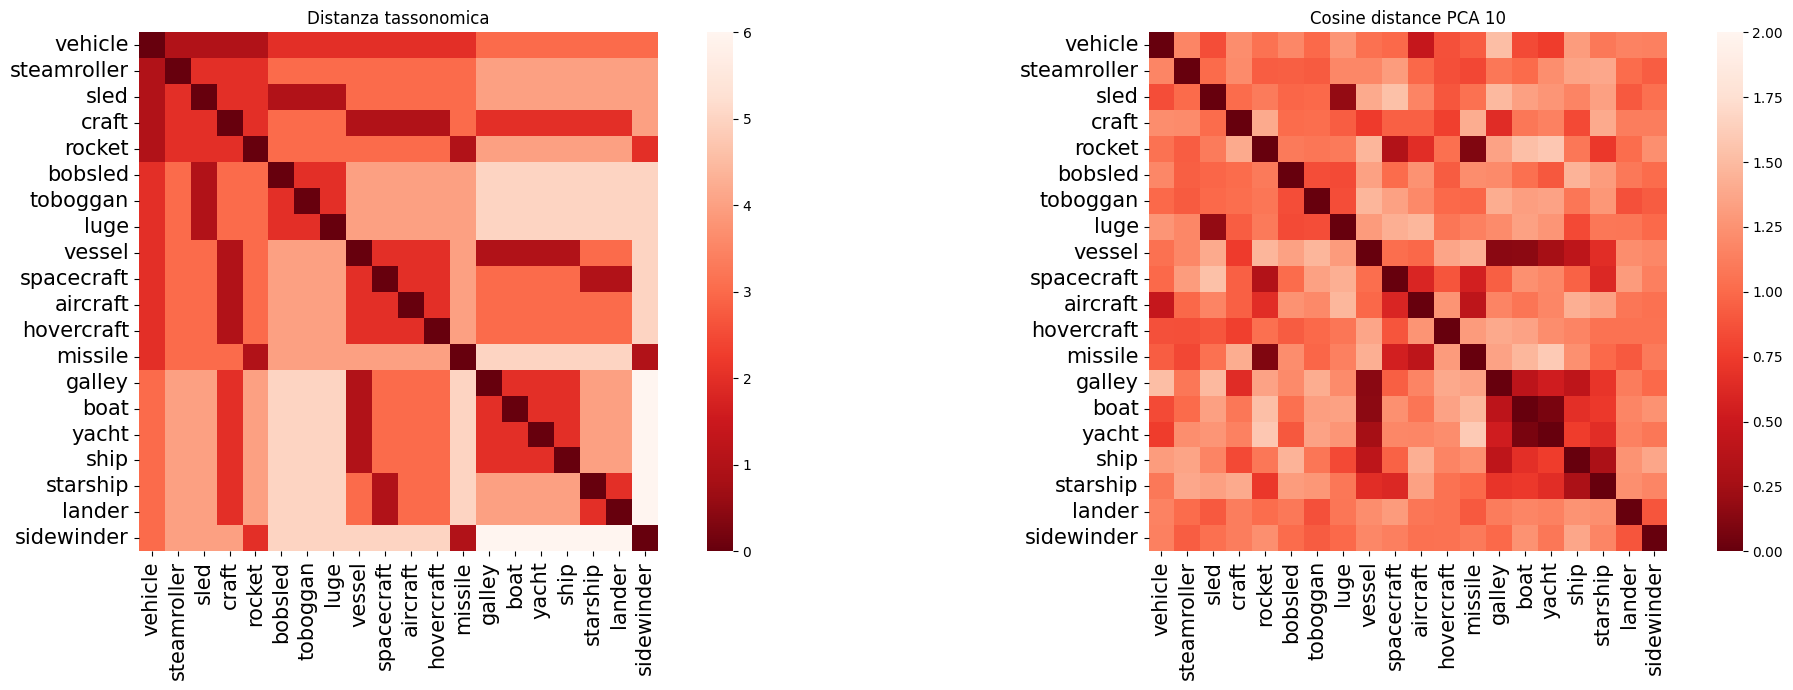

In [36]:
#Heatmap, prima faccio lista di matrici da visualizzare
mats = [dist_matrix,
        cosine_matrix_10.to_numpy()]  #la trasformo in un array

titles = ["Distanza Tassonomica",
        'Cosine Distance']

labels = [
    node.split('.', 1)[0]
    for node in sorted_keys
]

fig, axes = plt.subplots(1, 2, figsize=(21, 7))

# Taxonomic distance
sns.heatmap(
    dist_matrix,
     ax=axes[0],
     xticklabels=labels,
     yticklabels=labels,
     cmap="Reds_r",
     vmin=0,
     vmax=6,
     square=True
)

axes[0].set_title("Distanza tassonomica")
axes[0].tick_params(axis="x", rotation=90, labelsize=15)
axes[0].tick_params(axis="y", rotation=0, labelsize=15)

    # Cosine distance
sns.heatmap(
    cosine_matrix_10.to_numpy(),
    ax=axes[1],
    xticklabels=labels,
    yticklabels=labels,
    cmap="Reds_r",
    vmin=0,
    vmax=2,
    square=True
)

axes[1].set_title("Cosine distance PCA 10")
axes[1].tick_params(axis="x", rotation=90, labelsize=15)
axes[1].tick_params(axis="y", rotation=0, labelsize=15)

plt.tight_layout()

plt.savefig(
    "heatmap_confronto_distanze_PCA10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
#HEATMAP Distanza Tassonomica PCA 2
# creo una matrice 20x20 per la taxonomic distance
#step1: creo dataset duplicato con coppie inverse
df_inverso_2 = taxonomic_2_df.rename(
    columns={
        "word1": "word2",
        "word2": "word1"
    }
)
print(f"inverso:\n{df_inverso_2.head()}")

#step 2: unisco i dataset
df_completo_2 = pd.concat([taxonomic_2_df,df_inverso_2])

print(f"completo:\n{df_completo_2.head()}")
print(len(df_completo_2))

# ho già creato  lista ordinata di lemmi

#creo matrice di cosine distance a partire dal dataframe
cosine_matrix_2 = df_completo_2.pivot(
    index="word1",
    columns="word2",
    values="cosine_distance"
)

#cambio l'ordine degli elementi della matrice
cosine_matrix_2 = cosine_matrix_2.reindex(
    index=ordered_words,
    columns=ordered_words
)




inverso:
     word2       word1  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.942421         0.057579
1  vehicle     missile                   2           0.915753         0.084247
2  vehicle  sidewinder                   3          -0.563343         1.563343
3  vehicle       craft                   1          -0.909389         1.909389
4  vehicle    aircraft                   2           0.999830         0.000170
completo:
     word1       word2  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.942421         0.057579
1  vehicle     missile                   2           0.915753         0.084247
2  vehicle  sidewinder                   3          -0.563343         1.563343
3  vehicle       craft                   1          -0.909389         1.909389
4  vehicle    aircraft                   2           0.999830         0.000170
380


In [52]:
#associamo i valori Nan a 0 nella diagonale principale
cosine_matrix_2 = cosine_matrix_2.copy()

for word in cosine_matrix_2.index:
    cosine_matrix_2.loc[word, word] = 0

print(dist_matrix.shape)
print(cosine_matrix_2.shape)

print(cosine_matrix_2)
print(cosine_matrix_2.isna().sum().sum())

(20, 20)
(20, 20)
word2         vehicle  steamroller      sled     craft    rocket   bobsled  \
word1                                                                        
vehicle      0.000000     0.736182  1.608905  1.909389  0.057579  1.792450   
steamroller  0.736182     0.000000  0.395500  1.641124  0.428790  0.620735   
sled         1.608905     0.395500  0.000000  0.776216  1.308560  0.033645   
craft        1.909389     1.641124  0.776216  0.000000  1.996132  0.533055   
rocket       0.057579     0.428790  1.308560  1.996132  0.000000  1.542841   
bobsled      1.792450     0.620735  0.033645  0.533055  1.542841  0.000000   
toboggan     1.364552     0.197982  0.039368  1.055804  1.032146  0.143149   
luge         1.820413     0.664926  0.046893  0.491751  1.581957  0.001119   
vessel       1.140282     1.992043  1.699981  0.460595  1.463327  1.492738   
spacecraft   0.047247     1.041630  1.821080  1.740082  0.203687  1.940275   
aircraft     0.000170     0.718455  1.594186  

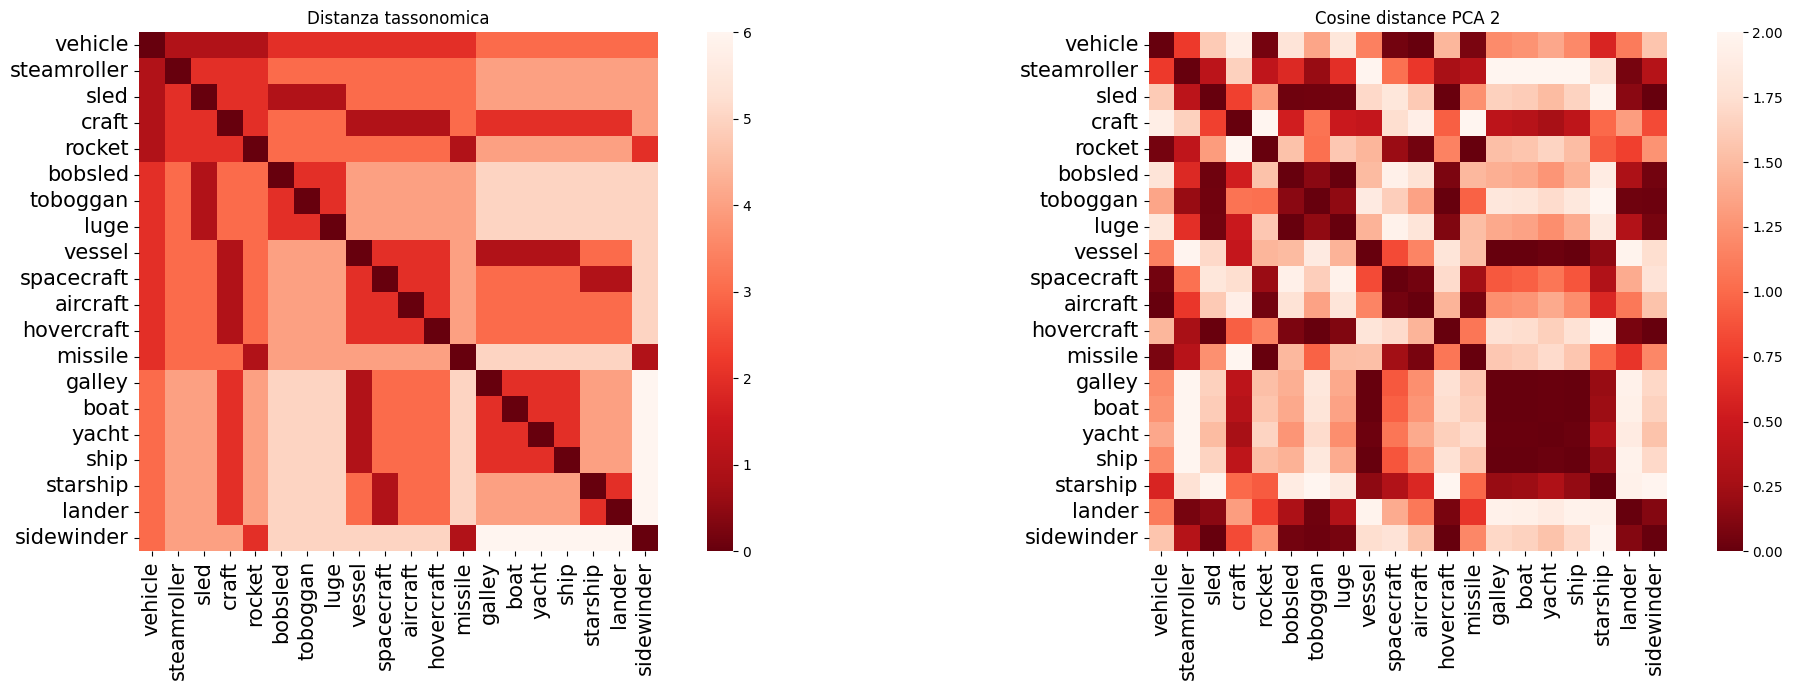

In [54]:
#Heatmap PCA 2, prima faccio lista di matrici da visualizzare
mats = [dist_matrix,
        cosine_matrix_2.to_numpy()]  #la trasformo in un array

titles = ["Distanza Tassonomica",
        'Cosine Distance']

labels = [
    node.split('.', 1)[0]
    for node in sorted_keys
]

fig, axes = plt.subplots(1, 2, figsize=(21, 7))

# Taxonomic distance
sns.heatmap(
    dist_matrix,
     ax=axes[0],
     xticklabels=labels,
     yticklabels=labels,
     cmap="Reds_r",
     vmin=0,
     vmax=6,
     square=True
)

axes[0].set_title("Distanza tassonomica")
axes[0].tick_params(axis="x", rotation=90, labelsize=15)
axes[0].tick_params(axis="y", rotation=0, labelsize=15)

    # Cosine distance
sns.heatmap(
    cosine_matrix_2.to_numpy(),
    ax=axes[1],
    xticklabels=labels,
    yticklabels=labels,
    cmap="Reds_r",
    vmin=0,
    vmax=2,
    square=True
)

axes[1].set_title("Cosine distance PCA 2")
axes[1].tick_params(axis="x", rotation=90, labelsize=15)
axes[1].tick_params(axis="y", rotation=0, labelsize=15)

plt.tight_layout()

plt.savefig(
    "heatmap_confronto_distanze_PCA2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
#correlazioni con il test di mantel
#PCA 10
coeff, p_value, n = mantel(dist_matrix, cosine_matrix_10)
print("PCA 10:\n")
print(f"rho = {round(coeff, 4)}")
print(f"p value = {round(p_value, 4)}")

#PCA 2
coeff, p_value, n = mantel(dist_matrix, cosine_matrix_2)
print("\nPCA 2:\n")
print(f"rho = {round(coeff, 4)}")
print(f"p value = {round(p_value, 4)}")

PCA 10:

rho = 0.3754
p value = 0.001

PCA 2:

rho = 0.2951
p value = 0.003


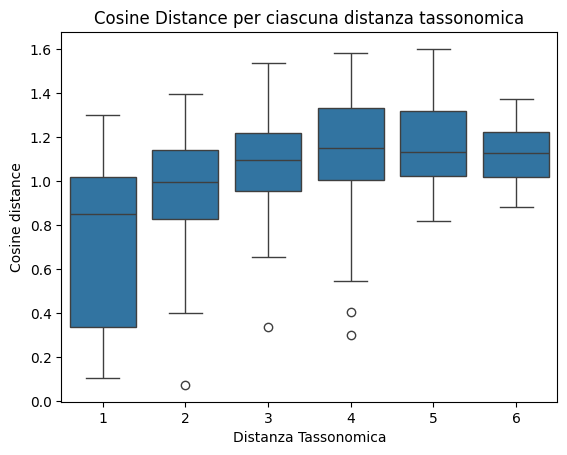

In [57]:
#PCA 10

sns.boxplot(
    data=taxonomic_10_df,
    x="taxonomic_distance",
    y="cosine_distance"
)

plt.xlabel("Distanza Tassonomica")
plt.ylabel("Cosine distance")
plt.title("Cosine Distance per ciascuna distanza tassonomica")
plt.show()

In [58]:
taxonomic_10_df.groupby("taxonomic_distance")["cosine_distance"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
taxonomic_distance,,,,,,,,
1,19.0,0.733,0.404,0.105,0.338,0.850,1.021,1.299
2,37.0,0.935,0.304,0.075,0.827,0.998,1.142,1.397
3,49.0,1.097,0.236,0.339,0.953,1.094,1.217,1.534
4,48.0,1.120,0.287,0.300,1.004,1.152,1.332,1.581
5,31.0,1.161,0.196,0.821,1.023,1.132,1.317,1.600
6,6.0,1.125,0.175,0.883,1.019,1.126,1.224,1.373


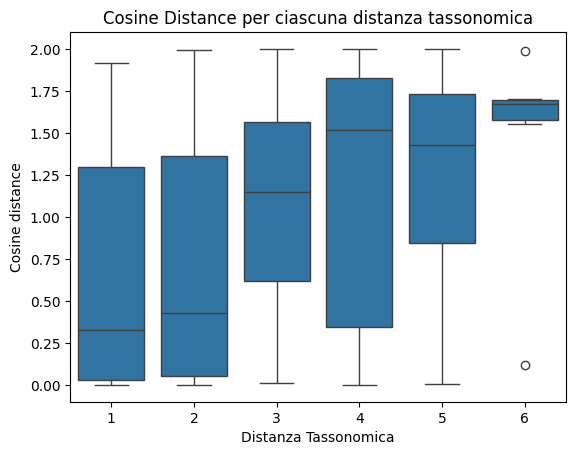

In [59]:
#PCA 2
sns.boxplot(
    data=taxonomic_2_df,
    x="taxonomic_distance",
    y="cosine_distance"
)

plt.xlabel("Distanza Tassonomica")
plt.ylabel("Cosine distance")
plt.title("Cosine Distance per ciascuna distanza tassonomica")
plt.show()

In [60]:
taxonomic_2_df.groupby("taxonomic_distance")["cosine_distance"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
taxonomic_distance,,,,,,,,
1,19.0,0.655,0.742,0.001,0.032,0.329,1.294,1.917
2,37.0,0.774,0.709,0.000,0.053,0.429,1.365,1.996
3,49.0,1.089,0.575,0.013,0.621,1.150,1.563,2.000
4,48.0,1.219,0.722,0.002,0.342,1.516,1.825,2.000
5,31.0,1.223,0.666,0.006,0.843,1.429,1.732,1.999
6,6.0,1.450,0.668,0.118,1.579,1.672,1.698,1.985


In [61]:
#riprendo output uscito nel dataset per l'albero
# vehicle
# ├── rocket
# │   ├── missile
# │   │   └── sidewinder
# ├── craft
# │   ├── aircraft
# │   ├── vessel
# │   │   └── galley
# │   │   └── ship
# │   │   └── yacht
# │   │   └── boat
# │   ├── hovercraft
# │   ├── spacecraft
# │   │   └── starship
# │   │   └── lander
# ├── steamroller
# ├── sled
# │   ├── bobsled
# │   ├── luge
# │   ├── toboggan

#dividiamo in cluster l'albero:
gruppi = {
    "rocket": ["rocket", "missile", "sidewinder"],
    
    "craft": [
        "craft", "aircraft", "vessel", "galley", "ship",
        "yacht", "boat", "hovercraft", "spacecraft",
        "starship", "lander"
    ],
    
    "steamroller": ["steamroller"],
    
    "sled": ["sled", "bobsled", "luge", "toboggan"]
}

In [63]:
#si crea set all words con dentro tutti gli elementi di albero
all_words = set()


all_words.update(taxonomic_tree["word1"])
all_words.update(taxonomic_tree["word2"])

print(all_words)
print(len(all_words))
# si attribuisce il gruppo a ogni parola dell'albero (all_words), 
y_true = []
#è lasciata fuori vehicles in quanto radice
for word in all_words:
    if word == "vehicle":
        continue

    for gruppo, parola_di_gruppo in gruppi.items(): #sfogliamo gli items del dizionario
        if word in parola_di_gruppo:
            y_true.append(gruppo)
            break

print(y_true)

{'ship', 'hovercraft', 'boat', 'vessel', 'galley', 'vehicle', 'bobsled', 'sled', 'steamroller', 'lander', 'yacht', 'spacecraft', 'sidewinder', 'missile', 'starship', 'toboggan', 'craft', 'aircraft', 'rocket', 'luge'}
20
['craft', 'craft', 'craft', 'craft', 'craft', 'sled', 'sled', 'steamroller', 'craft', 'craft', 'craft', 'rocket', 'rocket', 'craft', 'sled', 'craft', 'craft', 'rocket', 'sled']


In [77]:
#confronto ARI con 6 clusterizzazioni k-means, usando ARI, si vede qual è la migliore
def k_means_ARI (cosine_matrix_generica):
    X = np.array(cosine_matrix_generica)

    print(X.shape)
    #anche in questo caso tolgo vehicle in quanto radice
    X_19 = X[1:]

    #creo liste valori K-means e Ari, servono per il successivo grafico
    k_values = []
    ari_values = []

    for k in range(2, 7):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        y_pred = kmeans.fit_predict(X_19)

        ari = adjusted_rand_score(y_true, y_pred)

        k_values.append(k)
        ari_values.append(ari)

        print(f"k = {k}: ARI = {ari:.3f}")
        
    return  k_values, ari_values

In [79]:
#per PCA
print("PCA 10:\n")
k_means_10 = k_means_ARI (pca_10_embedding)

print("\nPCA 2:\n")
k_means_2 = k_means_ARI (pca_2_embedding)

PCA 10:

(20, 10)
k = 2: ARI = 0.162
k = 3: ARI = 0.061
k = 4: ARI = 0.030
k = 5: ARI = -0.046
k = 6: ARI = -0.068

PCA 2:

(20, 2)
k = 2: ARI = -0.055
k = 3: ARI = -0.022
k = 4: ARI = 0.011
k = 5: ARI = 0.067
k = 6: ARI = 0.093


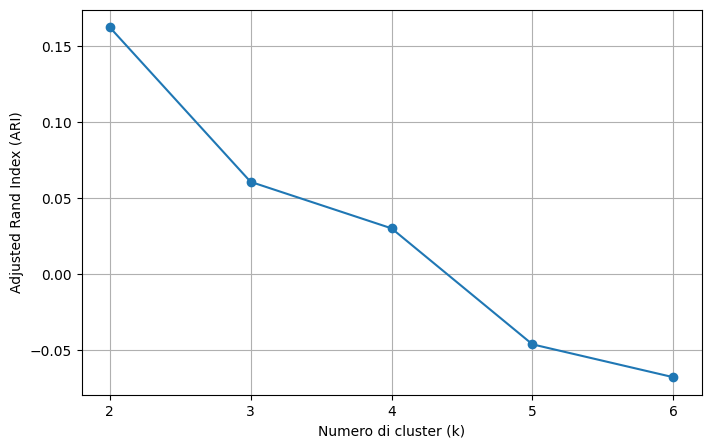

In [80]:
#grafico per capire quale k-mean è migliore
#per PCA 10
k_values_10, ari_values_10 = k_means_10
plt.figure(figsize=(8, 5))

plt.plot(
    k_values_10,
    ari_values_10,
    marker="o"
)

plt.xlabel("Numero di cluster (k)")
plt.ylabel("Adjusted Rand Index (ARI)")

plt.xticks(k_values_10)

plt.grid(True)

plt.savefig("ari_vs_k_in_PCA10.png", dpi=300, bbox_inches="tight")


plt.show()



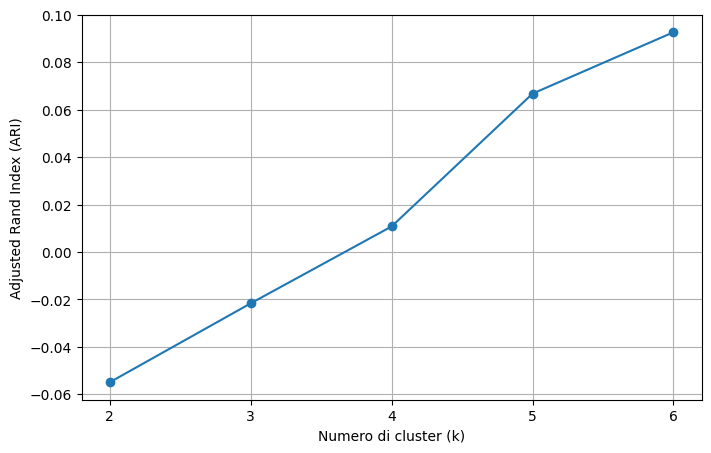

In [81]:
#grafico per capire quale k-mean è migliore
#per PCA 2
k_values_2, ari_values_2 = k_means_2
plt.figure(figsize=(8, 5))

plt.plot(
    k_values_2,
    ari_values_2,
    marker="o"
)

plt.xlabel("Numero di cluster (k)")
plt.ylabel("Adjusted Rand Index (ARI)")

plt.xticks(k_values_2)

plt.grid(True)

plt.savefig("ari_vs_k_in_PCA2.png", dpi=300, bbox_inches="tight")


plt.show()


In [90]:
#PCA 10 k migliore = 2

X_10 = np.array(pca_10_embedding)
#tolgo vehicle

X_19_10 = X_10[1:]

#k-means k=2 vince, vedo la ripartizione
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_19_10)

#ricreo la cosine matrix senza vehicle però
cosine_matrix_19_10 = cosine_matrix_10.drop(
    index="vehicle",
    columns="vehicle")

cluster_10_df = pd.DataFrame({
    "word": cosine_matrix_19_10.index,
    "cluster": clusters
})

cluster_10_df = cluster_10_df.sort_values("cluster")

print(cluster_10_df)


           word  cluster
7        vessel        0
12       galley        0
15         ship        0
14        yacht        0
3        rocket        1
0   steamroller        1
2         craft        1
1          sled        1
6          luge        1
5      toboggan        1
4       bobsled        1
8    spacecraft        1
11      missile        1
10   hovercraft        1
9      aircraft        1
13         boat        1
16     starship        1
17       lander        1
18   sidewinder        1


In [93]:
for cluster in sorted(cluster_10_df["cluster"].unique()):
    
    words = cluster_10_df[
        cluster_10_df["cluster"] == cluster
    ]["word"].tolist()
    
    print("Partizione secondo PCA 10\n")
    print(f"Cluster {cluster}:")
    print("  " + ", ".join(words))

Partizione secondo PCA 10

Cluster 0:
  vessel, galley, ship, yacht
Partizione secondo PCA 10

Cluster 1:
  rocket, steamroller, craft, sled, luge, toboggan, bobsled, spacecraft, missile, hovercraft, aircraft, boat, starship, lander, sidewinder


In [ ]:
#PCA 2  k migliore=6

X_2 = np.array(pca_2_embedding)
#tolgo vehicle

X_19_2 = X_2[1:]

#k-means k=2 vince, vedo la ripartizione
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_19_2)

#ricreo la cosine matrix senza vehicle però
cosine_matrix_19_2 = cosine_matrix_2.drop(
    index="vehicle",
    columns="vehicle")

cluster_2_df = pd.DataFrame({
    "word": cosine_matrix_19_2.index,
    "cluster": clusters
})

cluster_2_df = cluster_2_df.sort_values("cluster")

print(cluster_2_df)

           word  cluster
5      toboggan        0
1          sled        1
4       bobsled        1
3        rocket        1
16     starship        1
2         craft        2
10   hovercraft        2
13         boat        2
18   sidewinder        2
9      aircraft        2
6          luge        3
17       lander        3
15         ship        4
7        vessel        4
14        yacht        4
12       galley        4
8    spacecraft        5
11      missile        5
0   steamroller        5


In [92]:
for cluster in sorted(cluster_2_df["cluster"].unique()):
    
    words = cluster_2_df[
        cluster_2_df["cluster"] == cluster
    ]["word"].tolist()
    
    print("Partizione secondo PCA 2\n")
    print(f"Cluster {cluster}:")
    print("  " + ", ".join(words))

Partizione secondo PCA 2

Cluster 0:
  toboggan
Partizione secondo PCA 2

Cluster 1:
  sled, bobsled, rocket, starship
Partizione secondo PCA 2

Cluster 2:
  craft, hovercraft, boat, sidewinder, aircraft
Partizione secondo PCA 2

Cluster 3:
  luge, lander
Partizione secondo PCA 2

Cluster 4:
  ship, vessel, yacht, galley
Partizione secondo PCA 2

Cluster 5:
  spacecraft, missile, steamroller


In [94]:
# clustering gerarchico
#trasformo le matrici in forma scypy: estrae il triangolo superiore della matrice e lo convere in un vettore
#PCA 10
distance_vector_10 = squareform(cosine_matrix_19_10.values)

#PCA 2
distance_vector_2 = squareform(cosine_matrix_19_2.values)


In [95]:
#faccio confronto ARI tra combinazioni di metodi di Agglomerativeclustering e soglie k a cui raggruppare gli elementi
def Gerarchico_ARI (vettore_distanza):
    
    methods = ["single", "complete", "average"]

    finale = []

    for metodo in methods:
            
        Z = linkage(
            vettore_distanza,
            method=metodo
        )
        
        for k in range(2, 7):
            
            y_pred_hierarchical = fcluster(
                Z,
                t=k,
                criterion="maxclust"
                )
            
            ari = adjusted_rand_score(
                y_true,
                y_pred_hierarchical
                )

            finale.append({
                "linkage": metodo,
                "k": k,
                "ARI": ari
            })
            
            print(f"{metodo} | k = {k} | ARI = {ari:.3f}")
            
    return finale

In [98]:
#PCA 10
print("PCA 10:\n")
Gerarchico_10 = Gerarchico_ARI (distance_vector_10)
#PCA 2
print("\nPCA 2:\n")
Gerarchico_2 = Gerarchico_ARI (distance_vector_2)

PCA 10:

single | k = 2 | ARI = 0.073
single | k = 3 | ARI = 0.165
single | k = 4 | ARI = 0.257
single | k = 5 | ARI = 0.170
single | k = 6 | ARI = 0.177
complete | k = 2 | ARI = -0.077
complete | k = 3 | ARI = -0.060
complete | k = 4 | ARI = -0.097
complete | k = 5 | ARI = -0.072
complete | k = 6 | ARI = -0.059
average | k = 2 | ARI = 0.004
average | k = 3 | ARI = -0.060
average | k = 4 | ARI = -0.043
average | k = 5 | ARI = -0.072
average | k = 6 | ARI = -0.052

PCA 2:

single | k = 2 | ARI = -0.002
single | k = 3 | ARI = -0.066
single | k = 4 | ARI = -0.088
single | k = 5 | ARI = -0.092
single | k = 6 | ARI = -0.105
complete | k = 2 | ARI = -0.036
complete | k = 3 | ARI = -0.066
complete | k = 4 | ARI = -0.088
complete | k = 5 | ARI = -0.050
complete | k = 6 | ARI = -0.055
average | k = 2 | ARI = -0.036
average | k = 3 | ARI = -0.066
average | k = 4 | ARI = -0.088
average | k = 5 | ARI = -0.050
average | k = 6 | ARI = -0.055


In [99]:
#PCA10
# selezioniamo la combinazione che porta il risultato migliore
finale_10 = Gerarchico_10
best_result = max(finale_10, key=lambda x: x["ARI"])

print("\nMiglior configurazioneper PCA 10:")
print(f"Linkage: {best_result['linkage']}")
print(f"k: {best_result['k']}")
print(f"ARI: {best_result['ARI']:.3f}")


Miglior configurazioneper PCA 10:
Linkage: single
k: 4
ARI: 0.257


In [100]:
#PCA 2
# selezioniamo la combinazione che porta il risultato migliore
finale_2 = Gerarchico_2
best_result = max(finale_2, key=lambda x: x["ARI"])

print("\nMiglior configurazioneper PCA 2:")
print(f"Linkage: {best_result['linkage']}")
print(f"k: {best_result['k']}")
print(f"ARI: {best_result['ARI']:.3f}")


Miglior configurazioneper PCA 2:
Linkage: single
k: 2
ARI: -0.002


In [104]:
#dendrogramma PCA 10
#serve per la costruzione del dendogramma di "single"
Z_finale_10 = linkage(
        distance_vector_10,
        method = "single"
    )

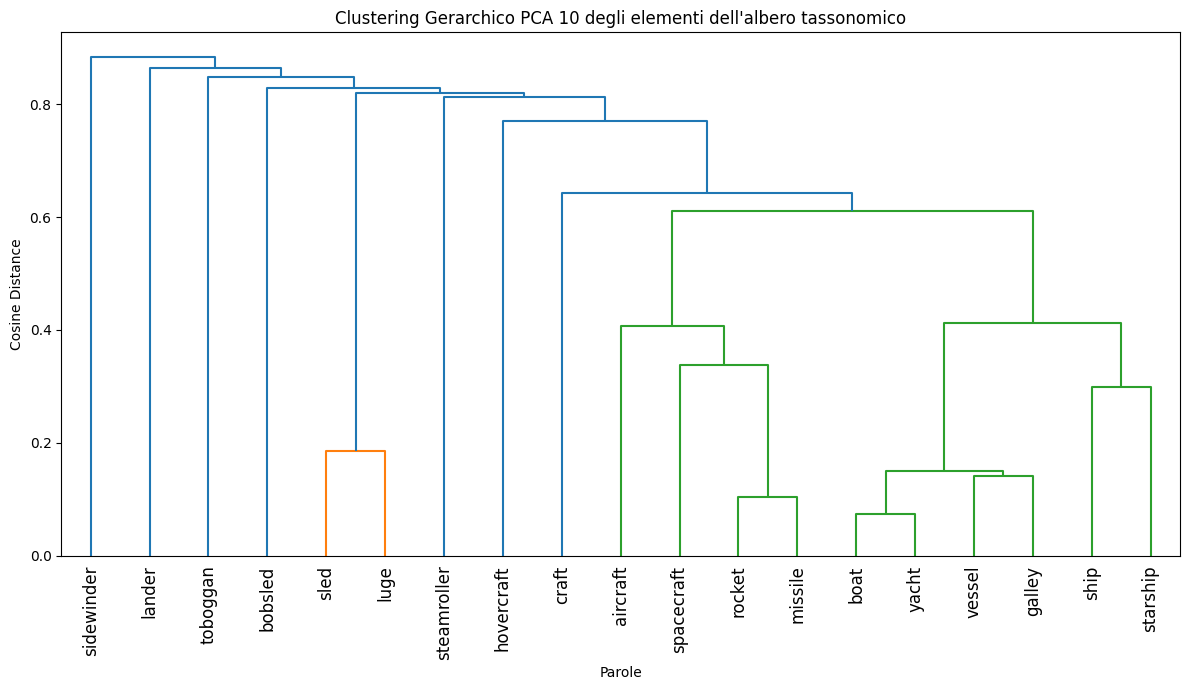

In [105]:
plt.figure(figsize=(12, 7))

dendrogram(
    Z_finale_10,
    labels=cosine_matrix_19_10.index.tolist(),
    leaf_rotation=90 #per visualizzare meglio il dendogramma
)

plt.xlabel("Parole")
plt.ylabel("Cosine Distance")
plt.title("Clustering Gerarchico PCA 10 degli elementi dell'albero tassonomico")

plt.tight_layout()
plt.show()

In [106]:
#dendrogramma PCA 2
#serve per la costruzione del dendogramma di "single"
Z_finale_2 = linkage(
        distance_vector_2,
        method = "single"
    )

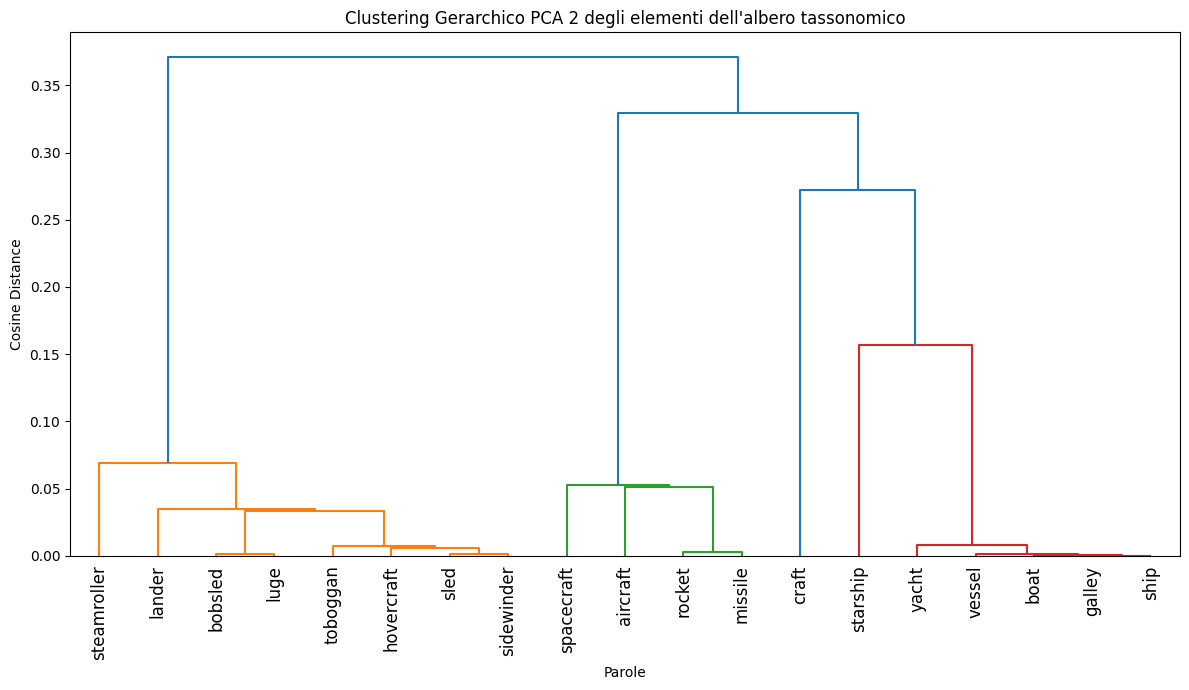

In [109]:
plt.figure(figsize=(12, 7))

dendrogram(
    Z_finale_2,
    labels=cosine_matrix_19_10.index.tolist(),
    leaf_rotation=90 #per visualizzare meglio il dendogramma
)

plt.xlabel("Parole")
plt.ylabel("Cosine Distance")
plt.title("Clustering Gerarchico PCA 2 degli elementi dell'albero tassonomico")

plt.tight_layout()
plt.show()